In [3]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:2,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:2,i_time] = maxI_
    return control_

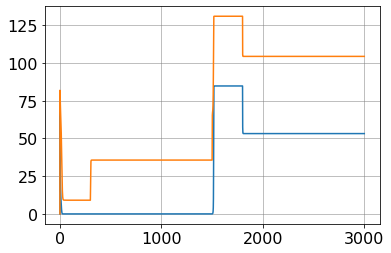

[[9.9409e-03 3.5642e+01]
 [5.3253e+01 1.0443e+02]]


In [8]:
aln = ALNModel()

aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.3
aln.params.ext_inh_current = 2.5

# NO ADAPTATION => else no bistability
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

# no noise
aln.params.sigma_ou = 0.

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

state = aln.getZeroState()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

output = aln.output_vars

for i in range(len(output)):
    state[:,i,:] = aln[output[i]][:,:]
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = np.mean(state[0,0,3000:15000]) # low state exc
steady_rates[0,1] = np.mean(state[0,1,3000:15000]) # low state inh
steady_rates[1,0] = np.mean(state[0,0,19500:]) # high state exc
steady_rates[1,1] = np.mean(state[0,1,19500:]) #high state inh

print(steady_rates)

state_vars = aln.state_vars
init_vars = aln.init_vars

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-2]

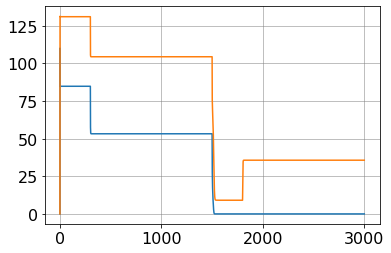

In [9]:
aln.params['duration'] = 3000.
control0 = step_control(maxI_ = -1.)
aln.run(control = control0)
plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-2]

In [10]:
def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][0] = vars[sv]
                    

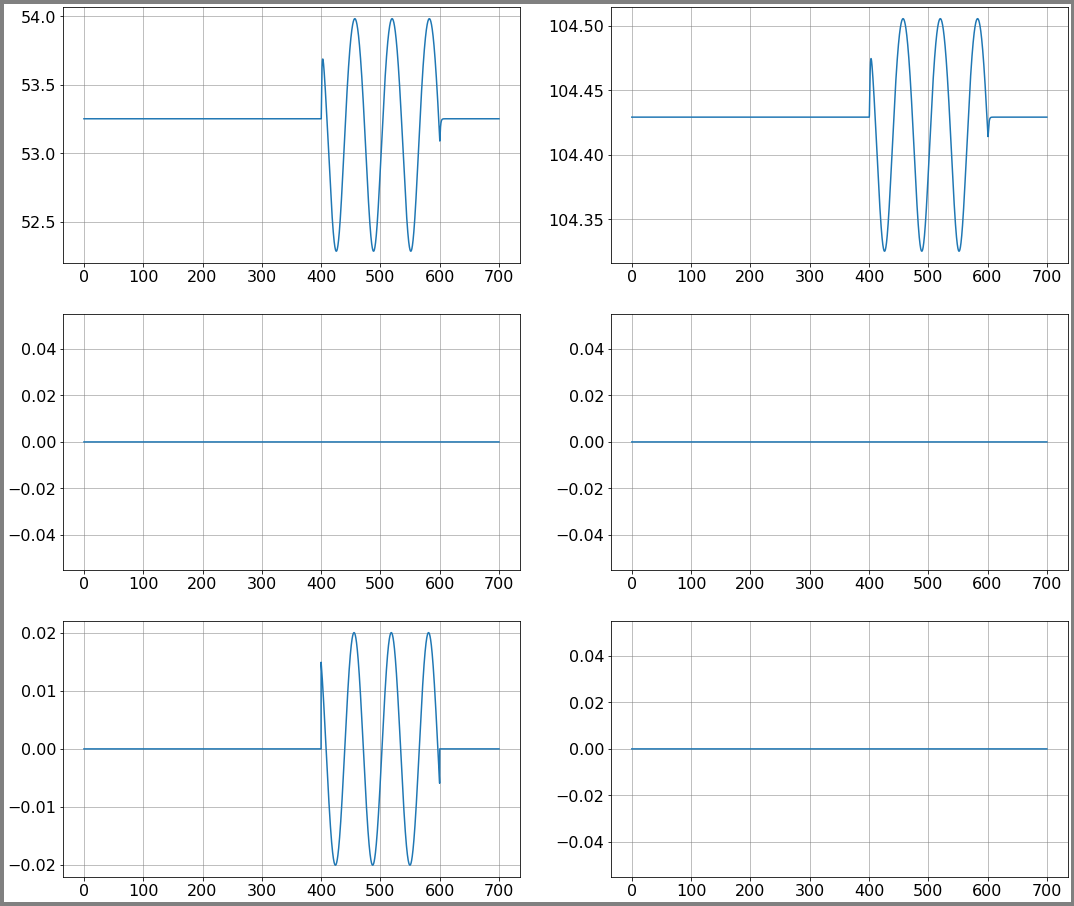

In [30]:
aln.params['duration'] = 700.

control0 = aln.getZeroControl()
control0[0,2,4000:6000] = 0.02 * np.sin(np.arange(40,60,0.01))
setinitvars(high_state_vars)

plotFunc.plot_traces(aln, control0)


In [38]:
max_it = 5
tol = 1e-12
incl_step = int(1. + aln.params.duration/aln.params.dt)
test_step = 1e-6

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

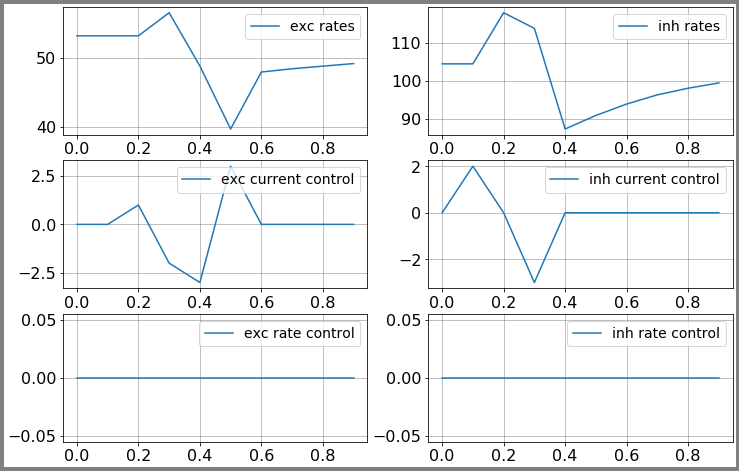

In [48]:
dur = .9
dur_pre = 0.5
dur_post = 0.5
aln.params.duration = dur

setinitvars(high_state_vars)

control0 = aln.getZeroControl()

control0[:,0,2] += 1.
control0[:,0,3] -= 2.
control0[:,0,4] -= 3.
control0[:,0,5] += 3.

control0[:,1,1] += 2.
control0[:,1,3] -= 3.

plotFunc.plot_traces(aln, control0)

# set high state rates as target
target = aln.getZeroTarget()
target[:,0,:] = aln.rates_exc[0,:]
target[:,1,:] = aln.rates_inh[0,:]

In [63]:
cost.setParams(1.0, 0., 0.0)
max_cntrl = 100. * 5.

setinitvars(high_state_vars)
max_it = 30
start_step = 10.
alg = "A1"
case = "test"

aln.params.duration = dur
control1 = aln.getZeroControl()
#control2 = bestControlA[:,:,5:15]

bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = "HZ",
        control_variables_ = [0,1,2,3], prec_variables_ = [0,1])

print("grad = ", grad)

for i in range(1, len(costA)):
    if costA[i-1] < costA[i]:
        print("ERROR ---------------- in index ", i)
        
print("total runtime = ", runtimeA[-1])

set cost params
RUN  0 , total integrated cost =  64.1891675079765
RUN  1 , total integrated cost =  28.231736772476236
RUN  2 , total integrated cost =  5.800258925847383
RUN  3 , total integrated cost =  2.3776553645410137
RUN  4 , total integrated cost =  0.8441961209674718
RUN  5 , total integrated cost =  0.5918018127771093
RUN  6 , total integrated cost =  0.3101851244493151
RUN  7 , total integrated cost =  0.18563782450828387
RUN  8 , total integrated cost =  0.07601451598878144
RUN  9 , total integrated cost =  0.05399949066445761
RUN  10 , total integrated cost =  0.029332823549691068
RUN  11 , total integrated cost =  0.02078710333823602
RUN  12 , total integrated cost =  0.007502696420315621
RUN  13 , total integrated cost =  0.00577459488389451
RUN  14 , total integrated cost =  0.0027247950692937
RUN  15 , total integrated cost =  0.001329246627033743
RUN  16 , total integrated cost =  0.0006277142318395552
RUN  17 , total integrated cost =  0.00021855745221650207
RUN  18

ERROR:root:Problem in initial value trasfer


RUN  26 , total integrated cost =  9.567371312289094e-07
RUN  27 , total integrated cost =  5.214164928034013e-07
RUN  28 , total integrated cost =  4.1544038808828783e-07
RUN  29 , total integrated cost =  2.72165358223413e-07
RUN  30 , total integrated cost =  1.397366675688147e-07
Improved over  30  iterations by  99.99999978230491  percent.
Problem in initial value trasfer:  Vmean_exc -56.70178496510985 -56.702142648644745
grad =  [[[ 0.          0.00196659  0.00150384 -0.00233182 -0.00215474
    0.00082271 -0.00087423  0.00290817 -0.0003942   0.        ]
  [ 0.         -0.00066142 -0.00136822  0.00225662  0.00167794
    0.00418912  0.00044116  0.00137363  0.00138782  0.        ]
  [ 0.          0.          0.          0.          0.
    0.          0.          0.          0.          0.        ]
  [ 0.          0.          0.          0.          0.
    0.          0.          0.          0.          0.        ]]]
total runtime =  6.087330000000293


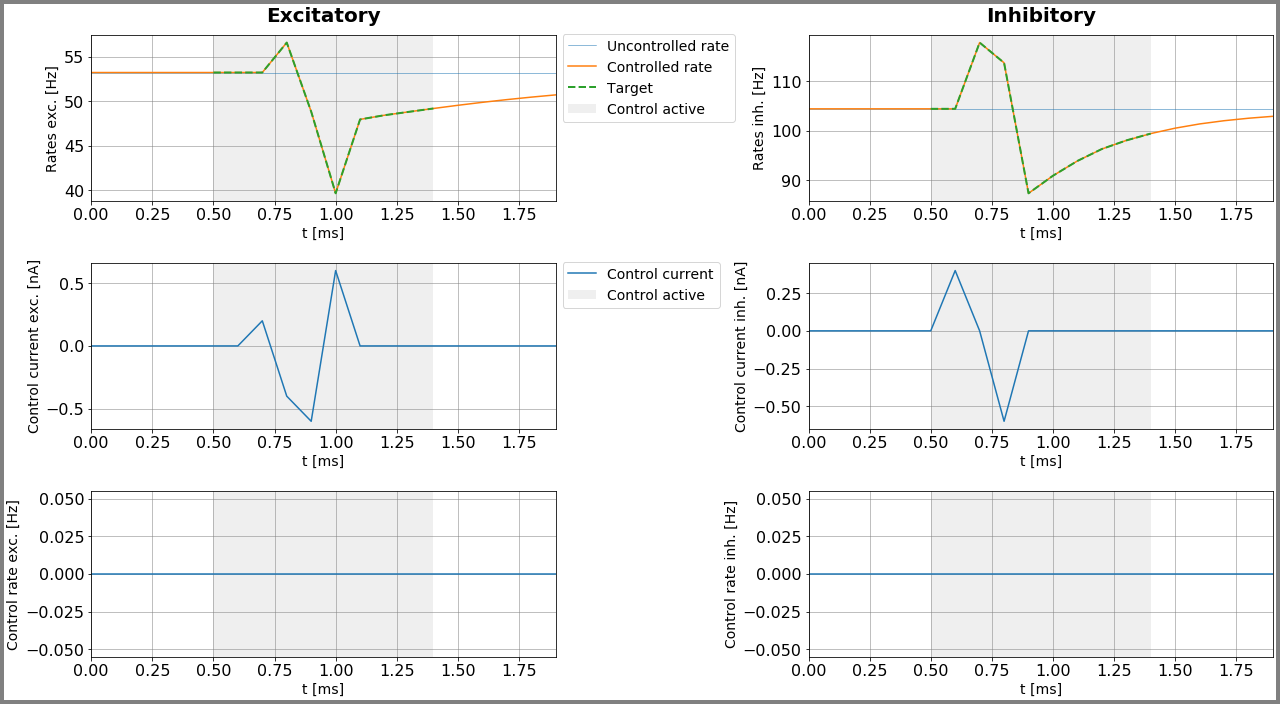

In [60]:
plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, high_state_vars, target, path)

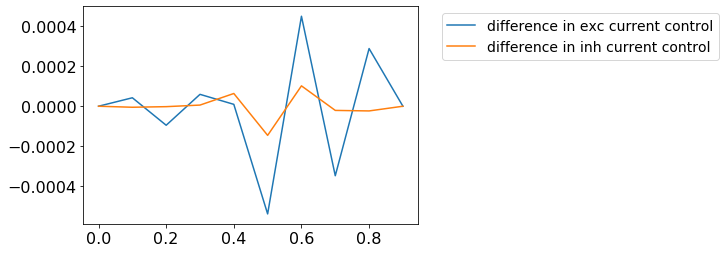

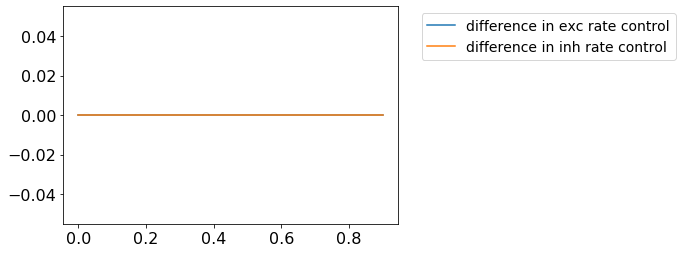

In [61]:
diff = control0 - bestControlA[0,:,5:15]

t = np.arange(0,dur+0.1, 0.1)

plt.plot(t, diff[0,0,:], label="difference in exc current control")
plt.plot(t, diff[0,1,:], label="difference in inh current control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

In [141]:
import sys
for path in sys.path:
    print(path)

D:\Promotion\neurolib\aln_control_20_11_12\test
D:\Promotion\neurolib
C:\Users\lenas\anaconda3\python37.zip
C:\Users\lenas\anaconda3\DLLs
C:\Users\lenas\anaconda3\lib
C:\Users\lenas\anaconda3

C:\Users\lenas\AppData\Roaming\Python\Python37\site-packages
C:\Users\lenas\anaconda3\lib\site-packages
C:\Users\lenas\anaconda3\lib\site-packages\win32
C:\Users\lenas\anaconda3\lib\site-packages\win32\lib
C:\Users\lenas\anaconda3\lib\site-packages\Pythonwin
C:\Users\lenas\anaconda3\lib\site-packages\IPython\extensions
C:\Users\lenas\.ipython
